In [1]:
import numpy as np
import finesse
import matplotlib.pyplot as plt
from utils.finesse_base import base_kat
from finesse.knm import Map
from finesse.utilities.maps import circular_aperture
from utils.sim import finesse_sim
from GNN.GNN_run import model_to_nx_port, run_GNN

## Check if the subspace created by ITM ROC and ETM ROC are different

In [2]:
ITM_ROC_nominal = -1934
ETM_ROC_nominal = 2245

ITM_ROC_List = np.linspace(ITM_ROC_nominal - 500, ITM_ROC_nominal + 500, 25)
ETM_ROC_List = np.linspace(ETM_ROC_nominal - 500, ETM_ROC_nominal + 500, 25)

#### Finesse simulation of this subspace

In [3]:
kat_sim = base_kat.deepcopy()
power_list = []
for ITM_roc in ITM_ROC_List:
    for ETM_roc in ETM_ROC_List:
        kat_sim.ITM.Rc = ITM_roc
        kat_sim.ETM.Rc = ETM_roc
        x = y = np.linspace(-0.17, 0.17, 100)

        kat_sim.ETM.surface_map = Map(x, y, amplitude=circular_aperture(x,y,0.17))
        
        if not kat_sim.cavArm.is_stable:
            power_list.append(-1)
            continue
        
        try:
            ref_power = kat_sim.run("""Series(
                            run_locks(max_iterations=100000,),
                            noxaxis(),
                            )""")
        except finesse.exceptions.LostLock as e:
            print(f"lock failed: {e}")
            power_list.append(-1)
            continue

  
        power_list.append(ref_power["noxaxis"]["p_ETM_p1_i"])

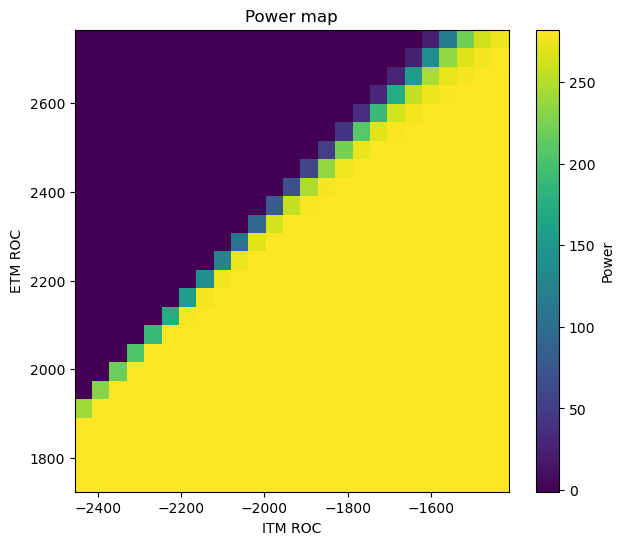

In [10]:
# Reshape the flattened power list into a 2D grid
power_grid = np.array(power_list).reshape(len(ETM_ROC_List), len(ITM_ROC_List))

# Create the mesh for plotting
X, Y = np.meshgrid(ITM_ROC_List, ETM_ROC_List)

plt.figure(figsize=(7, 6))
plt.pcolormesh(X, Y, power_grid, cmap='viridis', shading='auto')
plt.colorbar(label='Power')
plt.xlabel('ITM ROC')
plt.ylabel('ETM ROC')
plt.title('Power map')
plt.savefig("power_map_finesse.png")
plt.show()

#### GNN simulation of the subspace

In [11]:
kat_GNN = base_kat.deepcopy()
model_path = "GNN/models/power_predictor_ligo_fixed_gat10_kan5.pt"
pd_name = "ETM.p1.i"
power_list_GNN = []

for ITM_roc in ITM_ROC_List:
    for ETM_roc in ETM_ROC_List:
        kat_GNN.ITM.Rc = ITM_roc
        kat_GNN.ETM.Rc = ETM_roc

        name, powers = run_GNN(kat_GNN, model_path)

        index = name.index(pd_name)
        ref_power = powers[index]

        power_list_GNN.append(ref_power)

/home/ma/ligo-opt/GNN/GNN_run.py:67: RuntimeWarning: overflow encountered in exp
  powers = [np.exp(out[i].item()) for i in range(len(name))]


KeyboardInterrupt: 

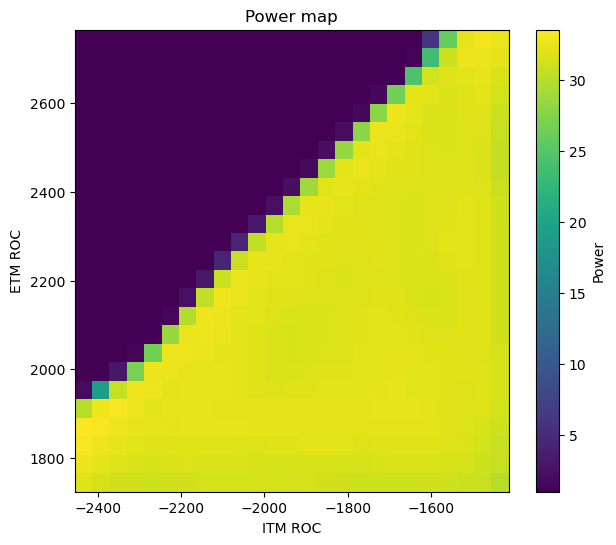

In [ ]:
# Reshape the flattened power list into a 2D grid
power_grid_GNN = np.array(power_list_GNN).reshape(len(ETM_ROC_List), len(ITM_ROC_List))

# Create the mesh for plotting
X, Y = np.meshgrid(ITM_ROC_List, ETM_ROC_List)

plt.figure(figsize=(7, 6))
plt.pcolormesh(X, Y, power_grid_GNN, cmap='viridis', shading='auto')
plt.colorbar(label='Power')
plt.xlabel('ITM ROC')
plt.ylabel('ETM ROC')
plt.title('Power map')
plt.savefig('power_map_GNN_old.png')
plt.show()